In [2]:
import numpy as np 
import cv2
import matplotlib 
from matplotlib import pyplot as plt 
%matplotlib inline

##### When we look at any image, most of the time we identify a person using a face. An image might contain multiple faces, also the face can be obstructed and not clear. The first step in our pre-processing pipeline is to detect faces from an image. Once face is detected, we will detect eyes, if two eyes are detected then only we keep that image otherwise discard it.

In [ ]:
# Load the image and print its shape using OpenCV imread function

In [3]:
img = cv2.imread("./test_images/abiy1.jpg")
print(img.shape)

(186, 271, 3)


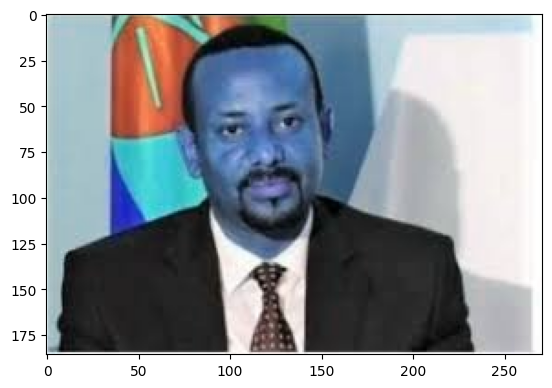

In [4]:
plt.imshow(img) # show the image using matplotlib

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # convert the image to grayscale using OpenCV cvtColor function
print(gray.shape)

(186, 271)


In [6]:
gray # show the array of the grayscale image every 
    # pixel value in the grayscale image is represented as a single intensity value between 0 and 255, 
    # where 0 represents black and 255 represents white.

array([[253, 230, 244, ..., 252, 252, 254],
       [247, 215, 215, ..., 252, 252, 254],
       [252, 213, 205, ..., 252, 252, 254],
       ...,
       [239, 157, 130, ..., 252, 252, 255],
       [228, 178, 147, ..., 254, 255, 255],
       [245, 234, 242, ..., 255, 254, 250]], shape=(186, 271), dtype=uint8)

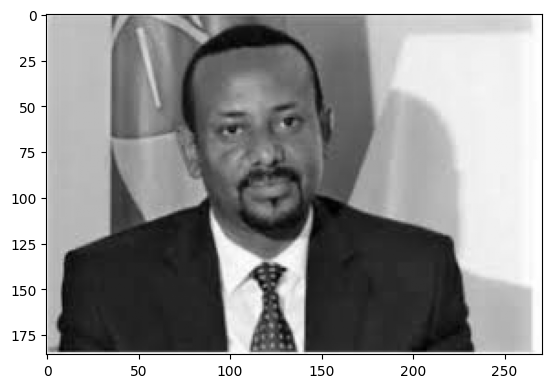

In [7]:
plt.imshow(gray, cmap='gray') # show the grayscale image using matplotlib with a colormap of 'gray'

In [9]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml') # load the Haar Cascade classifier for frontal face detection 
                                               # using OpenCV CascadeClassifier function
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml') # load the Haar Cascade classifier for eye detection 
                                               # using OpenCV CascadeClassifier function
faces = face_cascade.detectMultiScale(gray, 1.3, 5) # detect faces in the grayscale image using OpenCV detectMultiScale function and the numbers indicate the scale factor and minimum neighbors for the detection
faces

array([[78, 28, 84, 84]], dtype=int32)

In [10]:
if len(faces) == 0: # check if any faces were detected
    print("No faces detected.")
else:
    (x,y,w,h) = faces[0] # get the coordinates and dimensions of the first detected face
    x,y,w,h
x,y,w,h # print the coordinates and dimensions of the detected face    

(np.int32(78), np.int32(28), np.int32(84), np.int32(84))

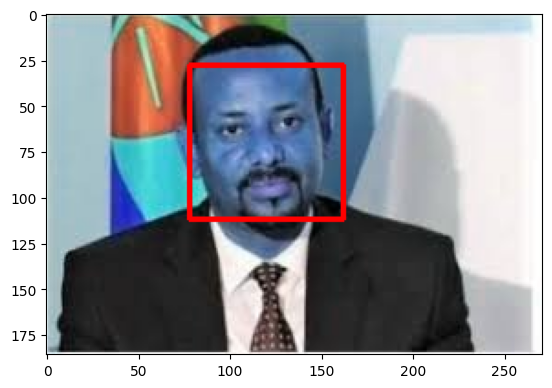

In [11]:
face_image = cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0),2) # draw a rectangle around the detected face using OpenCV rectangle function with the specified coordinates, color, and thickness
plt.imshow(face_image) # show the image with the detected face highlighted using matplotlib 